In [1]:
%load_ext autoreload
%autoreload 2

## Statistics

In [7]:
import pandas as pd
llama = pd.read_csv("results/gradnorm_llama.tsv", sep="\t")

In [ ]:
from collections import Counter
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
LAYER = "lm_head"
NORM  = "l1_norm"
results = [json.loads(f.read_text()) for f in sorted(RESULTS_DIR.glob("*.json"))]

predicted = Counter()
for r in results:
    step_agents = {int(s["step_idx"]): s["role"] for s in r["steps"]}
    scores = {
        int(log["step_idx"]): log.get(NORM, {}).get(LAYER)
        for log in r["logs"]
        if step_agents.get(int(log["step_idx"]), "").lower() != "human"
    }
    if not scores:
        continue
    top_step = min(scores, key=lambda k: scores[k])
    agentx = step_agents.get(top_step, "unknown")
    if "orchestrator" in agentx.lower():
        agentx = "Orchestrator"
    predicted[agentx] += 1

true_agents = Counter(r["metadata"]["mistake_agent"] for r in results)
pd.DataFrame({
    "predicted_top1": predicted,
    "true_mistake":   true_agents,
}).fillna(0).astype(int).sort_values("predicted_top1", ascending=False)

,predicted_top1,true_mistake
WebSurfer,39,33
Orchestrator,15,18
FileSurfer,4,3
Assistant,0,4


In [ ]:
"""
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
mistake_scores = []
normal_scores =  []

for each file in the RESULTS_DIR:
    data = load(file)
    scores = data["scores"]
    mistake_scores.append(scores[mistake_step])
    normal_scores.append(scores[normal_steps])

plot_distribution(mistake_scores, normal_scores)
"""

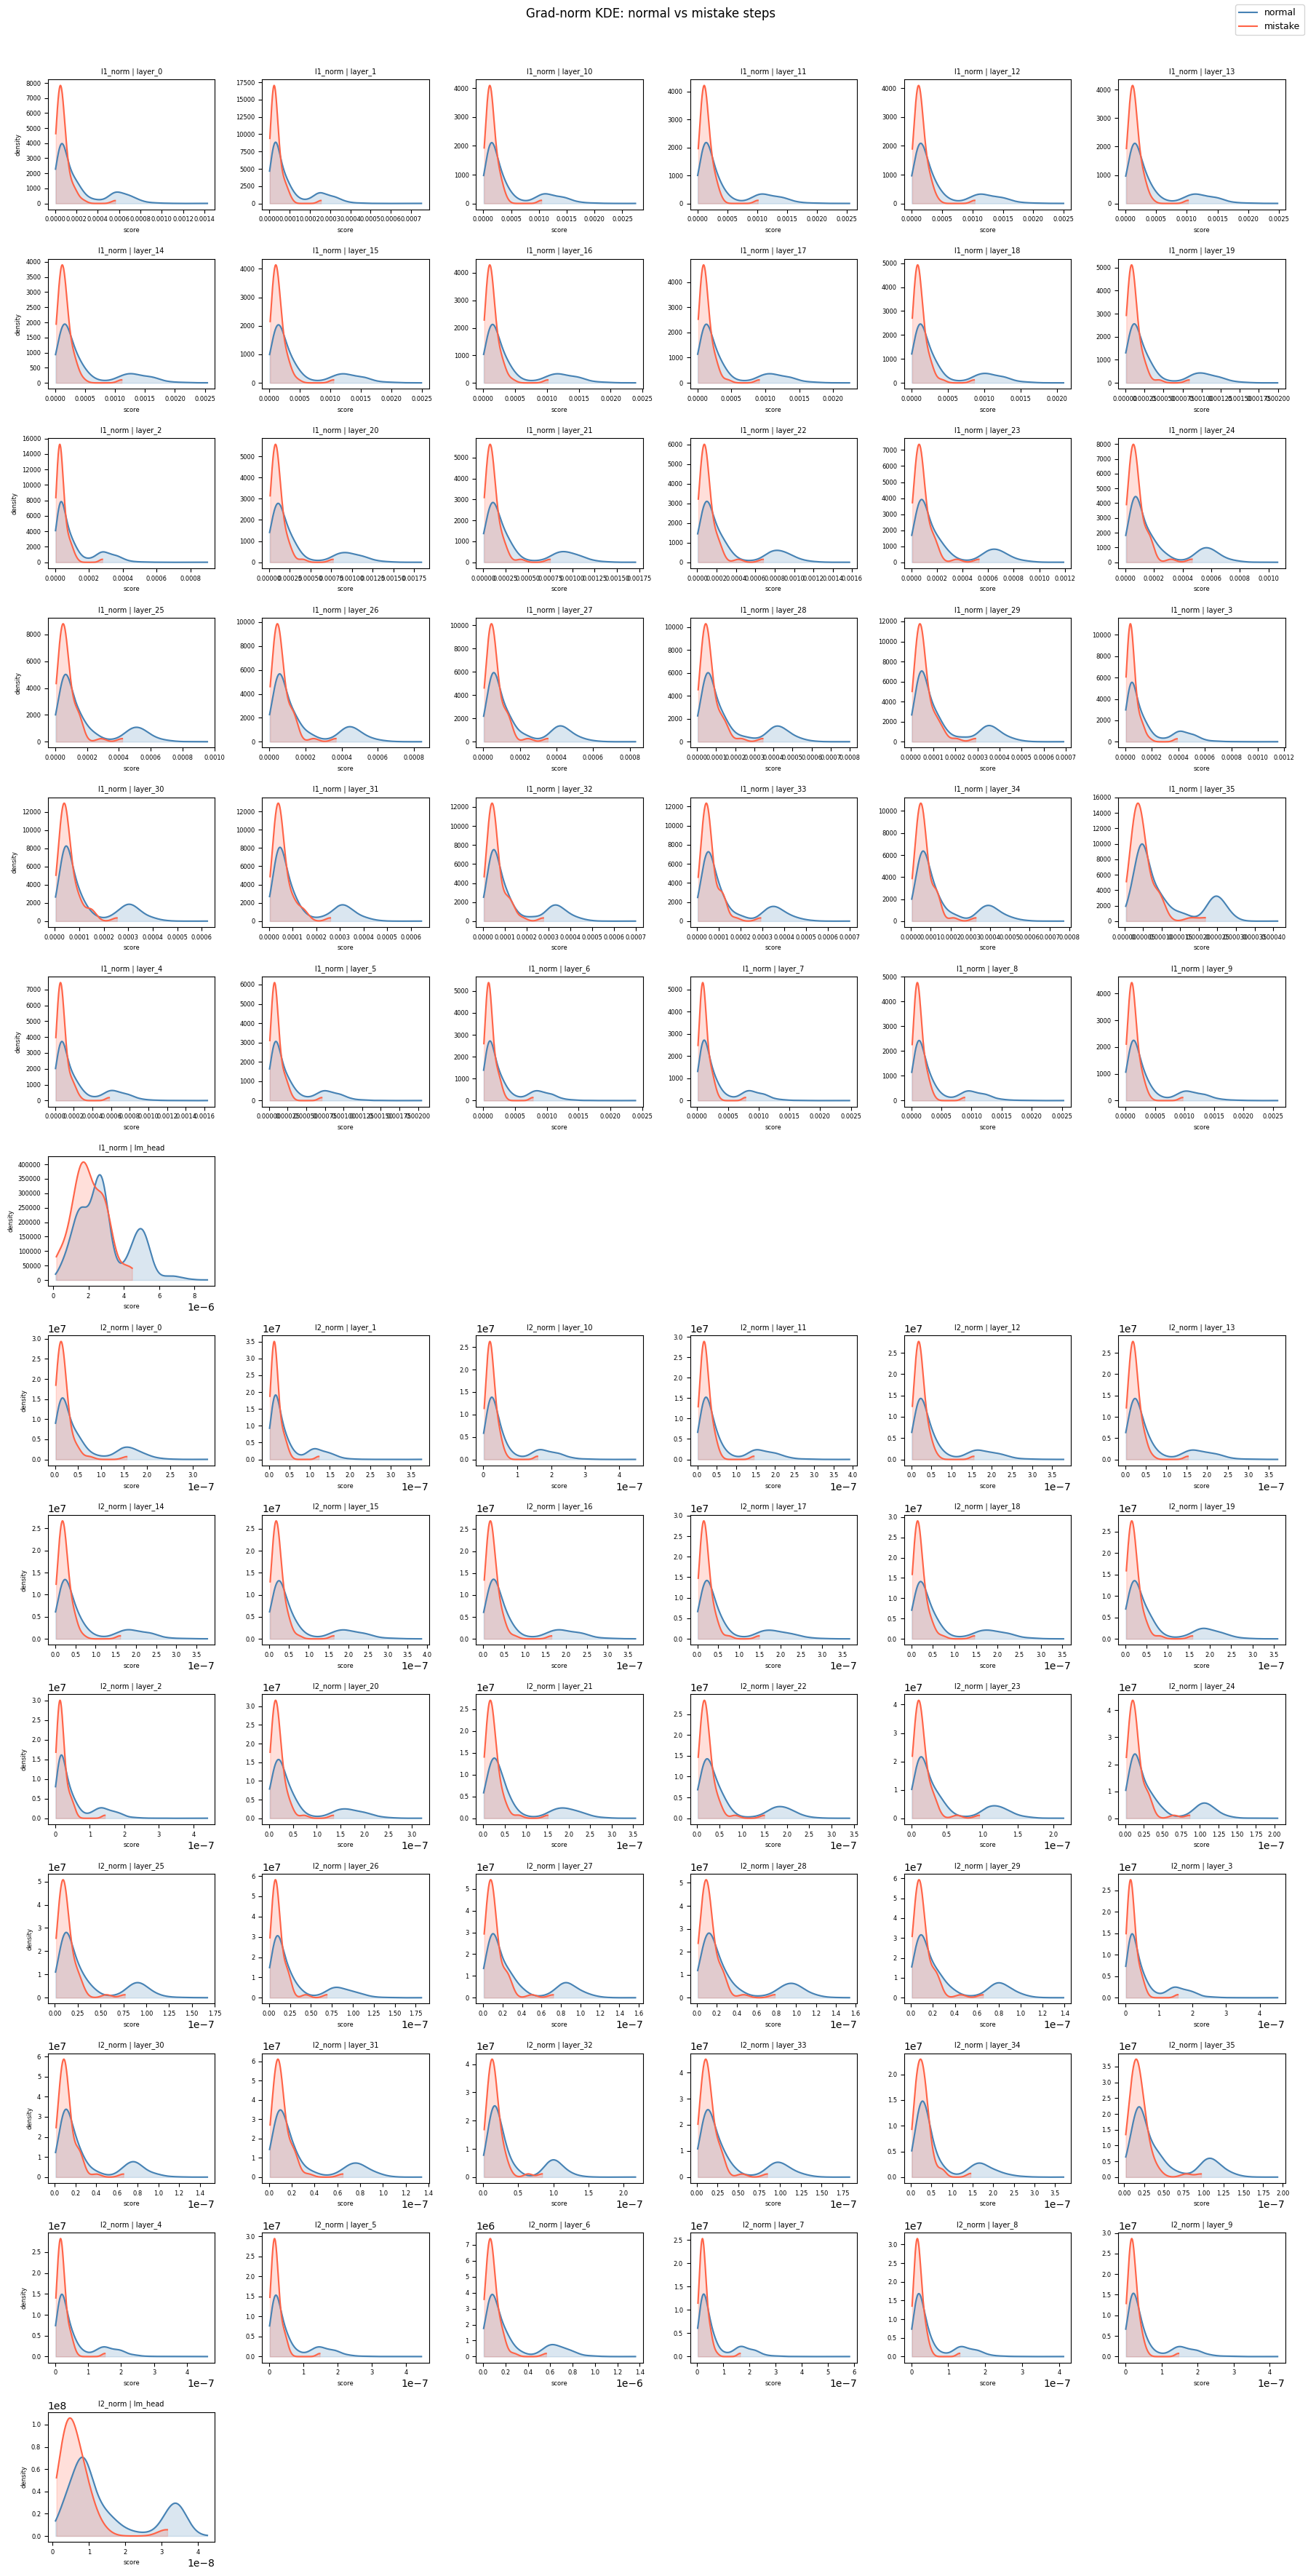

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

# ── config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
NORM_TYPES  = ["l1_norm", "l2_norm"]
NCOLS       = 6          # layer columns per row; tune as needed
KDE_POINTS  = 400        # resolution of the KDE curve

# ── collect scores ────────────────────────────────────────────────────────────
scores = {nt: defaultdict(lambda: {"mistake": [], "normal": []}) for nt in NORM_TYPES}

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    data         = json.loads(fpath.read_text())
    mistake_step = int(data["metadata"]["mistake_step"])

    for log in data["logs"]:
        step = int(log["step_idx"])
        kind = "mistake" if step == mistake_step else "normal"

        for nt in NORM_TYPES:
            for layer, val in log[nt].items():
                scores[nt][layer][kind].append(val)

# ── plot ──────────────────────────────────────────────────────────────────────
layers = sorted(scores[NORM_TYPES[0]].keys(),
                key=lambda x: (x == "lm_head", x))   # push lm_head to end
n_layers = len(layers)
n_rows_per_norm = (n_layers + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(
    nrows = len(NORM_TYPES) * n_rows_per_norm,
    ncols = NCOLS,
    figsize = (NCOLS * 3, len(NORM_TYPES) * n_rows_per_norm * 2.5),
)
axes = np.array(axes).reshape(len(NORM_TYPES), n_rows_per_norm, NCOLS)

def plot_kde(ax, values, label, color):
    if len(values) < 2:
        return
    arr = np.array(values)
    kde = gaussian_kde(arr)
    xs  = np.linspace(arr.min(), arr.max(), KDE_POINTS)
    ax.plot(xs, kde(xs), label=label, color=color)
    ax.fill_between(xs, kde(xs), alpha=0.2, color=color)

for ni, nt in enumerate(NORM_TYPES):
    for li, layer in enumerate(layers):
        row, col = divmod(li, NCOLS)
        ax = axes[ni, row, col]

        plot_kde(ax, scores[nt][layer]["normal"],  label="normal",  color="steelblue")
        plot_kde(ax, scores[nt][layer]["mistake"], label="mistake", color="tomato")

        ax.set_title(f"{nt} | {layer}", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("score", fontsize=6)
        if col == 0:
            ax.set_ylabel("density", fontsize=6)

    # hide unused axes in this norm block
    for li in range(n_layers, n_rows_per_norm * NCOLS):
        row, col = divmod(li, NCOLS)
        axes[ni, row, col].set_visible(False)

handles, labels = axes[0, 0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Grad-norm KDE: normal vs mistake steps", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_145480/1100696693.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(roles))


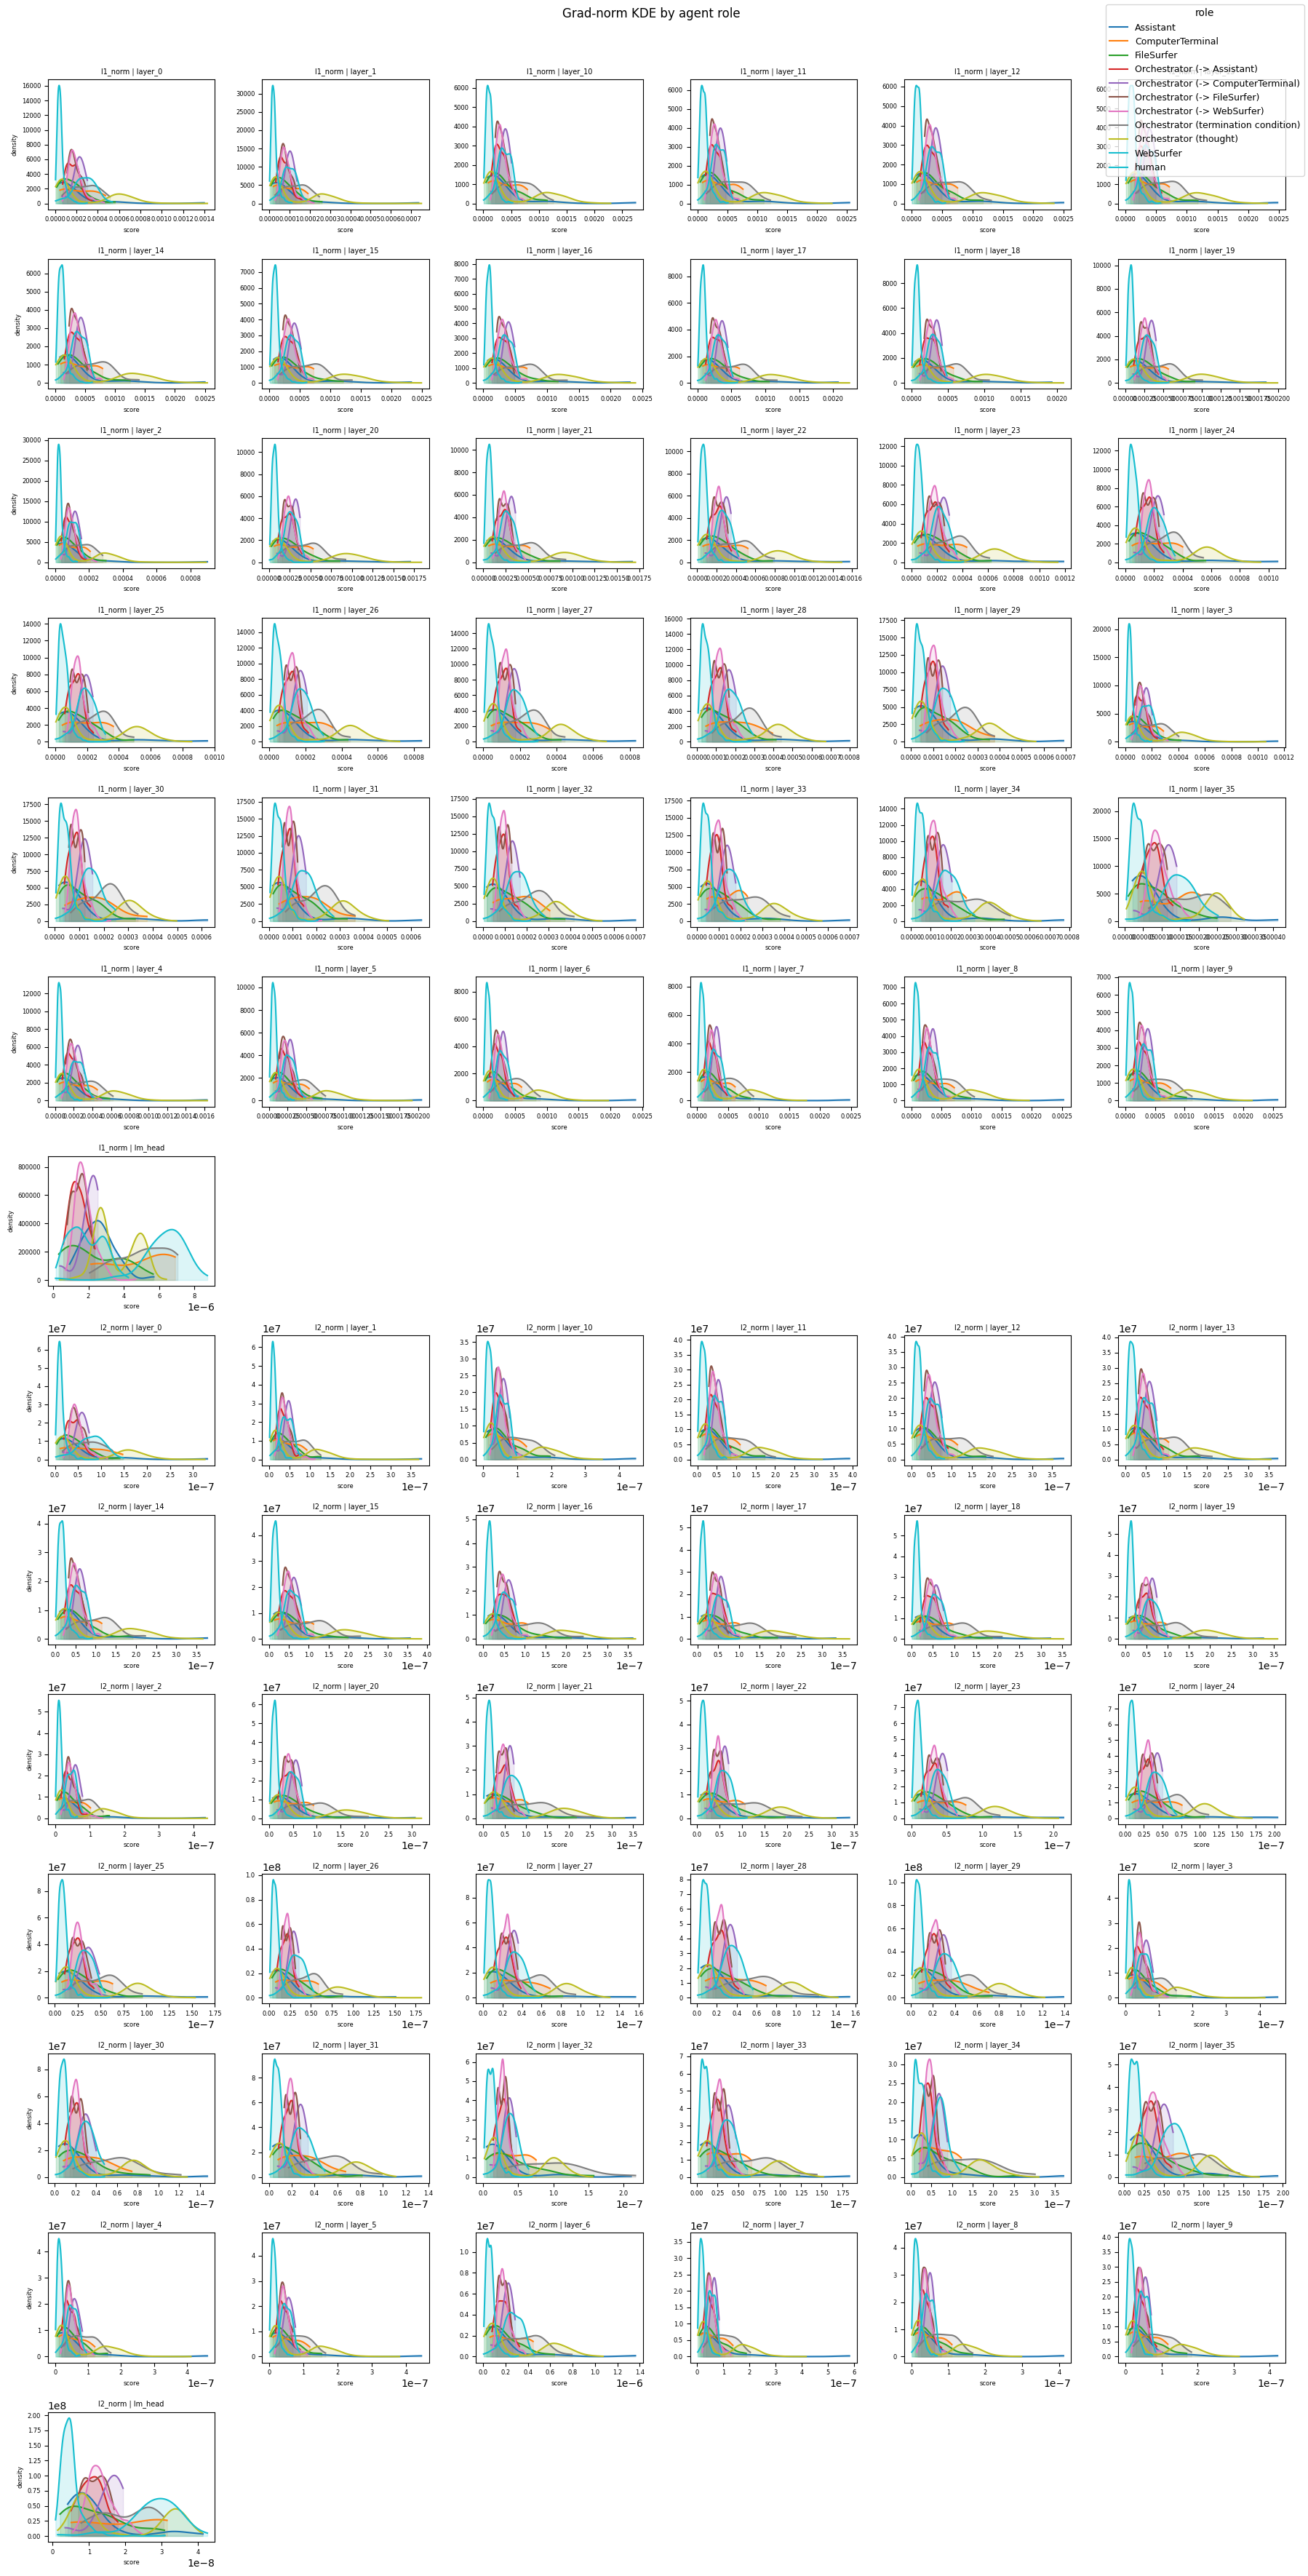

In [3]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

# ── config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
NORM_TYPES  = ["l1_norm", "l2_norm"]
NCOLS       = 6
KDE_POINTS  = 200

# ── collect scores keyed by role ──────────────────────────────────────────────
# scores[norm_type][layer][role] = [val, ...]
scores = {nt: defaultdict(lambda: defaultdict(list)) for nt in NORM_TYPES}
all_roles = set()

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    data = json.loads(fpath.read_text())

    # build step_idx -> role lookup
    step_role = {s["step_idx"]: s["role"] for s in data["steps"]}

    for log in data["logs"]:
        role = step_role.get(log["step_idx"], "unknown")
        all_roles.add(role)
        for nt in NORM_TYPES:
            for layer, val in log[nt].items():
                scores[nt][layer][role].append(val)

# ── colors ────────────────────────────────────────────────────────────────────
roles  = sorted(all_roles)
cmap   = plt.cm.get_cmap("tab10", len(roles))
colors = {role: cmap(i) for i, role in enumerate(roles)}

# ── plot ──────────────────────────────────────────────────────────────────────
layers = sorted(scores[NORM_TYPES[0]].keys(),
                key=lambda x: (x == "lm_head", x))
n_layers = len(layers)
n_rows_per_norm = (n_layers + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(
    nrows = len(NORM_TYPES) * n_rows_per_norm,
    ncols = NCOLS,
    figsize = (NCOLS * 3, len(NORM_TYPES) * n_rows_per_norm * 2.5),
)
axes = np.array(axes).reshape(len(NORM_TYPES), n_rows_per_norm, NCOLS)

def plot_kde(ax, values, label, color):
    if len(values) < 2:
        return
    arr = np.array(values)
    kde = gaussian_kde(arr)
    xs  = np.linspace(arr.min(), arr.max(), KDE_POINTS)
    ax.plot(xs, kde(xs), label=label, color=color)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=color)

for ni, nt in enumerate(NORM_TYPES):
    for li, layer in enumerate(layers):
        row, col = divmod(li, NCOLS)
        ax = axes[ni, row, col]

        for role in roles:
            plot_kde(ax, scores[nt][layer][role], label=role, color=colors[role])

        ax.set_title(f"{nt} | {layer}", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("score", fontsize=6)
        if col == 0:
            ax.set_ylabel("density", fontsize=6)

    for li in range(n_layers, n_rows_per_norm * NCOLS):
        row, col = divmod(li, NCOLS)
        axes[ni, row, col].set_visible(False)

handles, labels = axes[0, 0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9, title="role")
fig.suptitle("Grad-norm KDE by agent role", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ── config ────────────────────────────────────────────────────────────────────
# RESULTS_DIR = Path("outputs/qwen3-8b/grad-norm/hand-crafted")
RESULTS_DIR = Path("ablation/qwen3-8b/hand-crafted")
NORM_TYPE   = "l2_norm"
# LAYER       = "lm_head"
K = 1

# Patterns are matched against param names like:
#   "model.layers.0.self_attn.q_proj.weight"
#   "model.layers.0.mlp.gate_proj.weight"
#   "lm_head.weight"
# Use {i} as a placeholder for layer index; None = aggregate all layers.

N_LAYERS = 36  # Qwen3-8B

layer_configs = {f"layer_{i}": rf"model\.layers\.{i}\."   for i in range(N_LAYERS)}
mlp_configs   = {f"layer_{i}":  rf"model\.layers\.{i}\.mlp\."       for i in range(N_LAYERS)}
attn_configs  = {f"layer_{i}": rf"model\.layers\.{i}\.self_attn\." for i in range(N_LAYERS)}

PATTERN = attn_configs['layer_35']
# PATTERN = mlp_configs['layer_30']
# PATTERN = layer_configs['layer_35']
# PATTERN = "lm_head"
# ── helpers ───────────────────────────────────────────────────────────────────
def aggregate(statistics: dict, param_names: list[str], norm_type: str, normalize: bool = True) -> float:
    """
    Aggregate per-parameter stats into a single scalar.
    l2_norm_sq decomposes additively; take sqrt only at the end.
    """
    l1, l2_sq, n = 0.0, 0.0, 0
    for name in param_names:
        s = statistics[name]
        l1    += s["l1_norm"]
        l2_sq += s["l2_norm_sq"]
        n     += s["n_params"]
    if n == 0:
        return float("nan")
    if norm_type == "l1_norm":
        return l1 / n if normalize else l1
    elif norm_type == "l2_norm":
        return (math.sqrt(l2_sq) / n) if normalize else math.sqrt(l2_sq)


def get_score(log: dict, norm_type: str, pattern: str, normalize: bool = True) -> float:
    """
    Compute an aggregated norm score for all parameters whose name matches `pattern`.

    `pattern` can be:
      - a regex string  e.g. r"model\\.layers\\.0\\.self_attn"
      - a plain key     e.g. "lm_head"  (matched as substring)
    """
    statistics = log["statistics"]
    matched = [k for k in statistics if re.search(pattern, k)]
    if not matched:
        return float("nan")
    return aggregate(statistics, matched, norm_type, normalize)


# ── evaluate each trajectory ──────────────────────────────────────────────────
rows = []

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    data          = json.loads(fpath.read_text())
    meta          = data["metadata"]
    mistake_step  = int(meta["mistake_step"])
    mistake_agent = meta["mistake_agent"]

    step_scores = [
        (log["step_idx"], get_score(log, NORM_TYPE, PATTERN))
        for log in data["logs"]
        if log.get("statistics")   # skip degenerate steps that have no statistics
    ]
    step_roles = {s["step_idx"]: s["role"] for s in data["steps"]}

    ranked_steps = sorted(step_scores, key=lambda x: x[1], reverse=False)
    pred_steps   = [step[0] for step in ranked_steps[:K]]
    pred_agents  = [step_roles.get(idx, "unknown") for idx in pred_steps]
    pred_agents  = [
        "Orchestrator" if "orchestrator" in a.lower() else a
        for a in pred_agents
    ]

    rows.append({
        "mistake_agent": mistake_agent,
        "step_correct":  int(mistake_step in pred_steps),
        "agent_correct": int(mistake_agent in pred_agents),
    })

# ── aggregate ─────────────────────────────────────────────────────────────────
df = pd.DataFrame(rows)

table = (
    df.groupby("mistake_agent")
      .agg(
          n_trajectories = ("step_correct", "count"),
          step_acc       = ("step_correct",  "mean"),
          agent_acc      = ("agent_correct", "mean"),
      )
      .sort_values("n_trajectories", ascending=False)
)
table["step_acc"]  = table["step_acc"].map("{:.1%}".format)
table["agent_acc"] = table["agent_acc"].map("{:.1%}".format)

overall = pd.DataFrame([{
    "mistake_agent":  "OVERALL",
    "n_trajectories": len(df),
    "step_acc":       "{:.1%}".format(df["step_correct"].mean()),
    "agent_acc":      "{:.1%}".format(df["agent_correct"].mean()),
}]).set_index("mistake_agent")

table = pd.concat([table, overall])
table

,n_trajectories,step_acc,agent_acc
mistake_agent,,,
WebSurfer,31,16.1%,51.6%
Orchestrator,17,17.6%,58.8%
Assistant,4,25.0%,25.0%
FileSurfer,3,0.0%,33.3%
OVERALL,55,16.4%,50.9%


In [29]:
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ── config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("ablation/qwen3-8b/hand-crafted")
NORM_TYPE   = "l2_norm"
K           = 10
N_LAYERS    = 36

layer_configs = {f"layer/{i}": rf"model\.layers\.{i}\."           for i in range(N_LAYERS)}
mlp_configs   = {f"mlp/{i}":   rf"model\.layers\.{i}\.mlp\."     for i in range(N_LAYERS)}
attn_configs  = {f"attn/{i}":  rf"model\.layers\.{i}\.self_attn\." for i in range(N_LAYERS)}
all_configs   = layer_configs | mlp_configs | attn_configs | {"lm_head": "lm_head"}

config_names   = list(all_configs.keys())
config_patterns = list(all_configs.values())

# ── pre-load ──────────────────────────────────────────────────────────────────
trajectories = [json.loads(f.read_text()) for f in sorted(RESULTS_DIR.glob("*.json"))]

# ── step 1: precompute config→param mask once ─────────────────────────────────
# param names are the same across all logs — grab from first valid log
sample_stats = next(
    log["statistics"]
    for data in trajectories
    for log in data["logs"]
    if log.get("statistics")
)
param_names = list(sample_stats.keys())
n_params    = len(param_names)
n_configs   = len(config_names)

# (n_configs, n_params) boolean matrix
mask_matrix = np.array(
    [[bool(re.search(pat, p)) for p in param_names] for pat in config_patterns],
    dtype=np.float64,
)  # precomputed once — ~109 configs × ~300 params, negligible

n_params_per_config = mask_matrix @ np.array(
    [sample_stats[p]["n_params"] for p in param_names], dtype=np.float64
)  # (n_configs,)

# ── step 2: score all configs for a log in one pass ───────────────────────────
def score_log_all_configs(log: dict) -> np.ndarray:
    """Returns (n_configs,) array of scores for the given log."""
    stats = log["statistics"]
    if NORM_TYPE == "l2_norm":
        vals = np.array([stats[p]["l2_norm_sq"] for p in param_names], dtype=np.float64)
        # (n_configs,): sum l2_sq per config, then sqrt and normalize
        sums = mask_matrix @ vals                          # (n_configs,)
        with np.errstate(invalid="ignore"):
            scores = np.sqrt(sums) / np.where(n_params_per_config > 0, n_params_per_config, np.nan)
    else:
        vals = np.array([stats[p]["l1_norm"] for p in param_names], dtype=np.float64)
        sums = mask_matrix @ vals
        with np.errstate(invalid="ignore"):
            scores = sums / np.where(n_params_per_config > 0, n_params_per_config, np.nan)
    return scores  # (n_configs,)

# ── sweep: single pass over trajectories ─────────────────────────────────────
# accumulators: (n_configs,)
step_correct_sum  = np.zeros(n_configs)
agent_correct_sum = np.zeros(n_configs)
n_total           = 0

for data in trajectories:
    meta          = data["metadata"]
    mistake_step  = int(meta["mistake_step"])
    mistake_agent = meta["mistake_agent"]
    step_roles    = {s["step_idx"]: s["role"] for s in data["steps"]}

    valid_logs = [log for log in data["logs"] if log.get("statistics")]
    if not valid_logs:
        continue

    # (n_logs, n_configs)
    score_matrix = np.stack([score_log_all_configs(log) for log in valid_logs])
    step_indices = np.array([log["step_idx"] for log in valid_logs])  # (n_logs,)

    # For each config, find top-K lowest-score steps
    # argsort along n_logs axis → (n_logs, n_configs)
    ranked = np.argsort(score_matrix, axis=0)[:K]  # (K, n_configs)
    pred_step_matrix = step_indices[ranked]         # (K, n_configs)

    step_correct  = np.any(pred_step_matrix == mistake_step, axis=0).astype(float)

    # agent_correct: check if mistake_agent is among pred_agents for each config
    def agent_correct_for_config(pred_steps_col):
        pred_agents = [step_roles.get(idx, "unknown") for idx in pred_steps_col]
        pred_agents = ["Orchestrator" if "orchestrator" in a.lower() else a for a in pred_agents]
        return float(mistake_agent in pred_agents)

    agent_correct = np.array([
        agent_correct_for_config(pred_step_matrix[:, c]) for c in range(n_configs)
    ])

    step_correct_sum  += step_correct
    agent_correct_sum += agent_correct
    n_total           += 1

# ── results ───────────────────────────────────────────────────────────────────
sweep_df = pd.DataFrame({
    "config":    config_names,
    "group":     [c.split("/")[0] for c in config_names],
    "layer_idx": pd.array([c.split("/")[1] if "/" in c else None for c in config_names]),
    "n":         n_total,
    "step_acc":  step_correct_sum  / n_total,
    "agent_acc": agent_correct_sum / n_total,
}).sort_values("step_acc", ascending=False).reset_index(drop=True)

print(f"=== Top-10 by step_acc (K={K}, {NORM_TYPE}) ===")
print(sweep_df.assign(
    step_acc  = sweep_df["step_acc"].map("{:.1%}".format),
    agent_acc = sweep_df["agent_acc"].map("{:.1%}".format),
).head(10).to_string(index=False))

print(f"\n=== Best per group ===")
best = (
    sweep_df.sort_values("step_acc", ascending=False)
            .groupby("group", sort=False).first().reset_index()
            [["group", "config", "layer_idx", "step_acc", "agent_acc"]]
)
best["step_acc"]  = best["step_acc"].map("{:.1%}".format)
best["agent_acc"] = best["agent_acc"].map("{:.1%}".format)
print(best.to_string(index=False))

=== Top-10 by step_acc (K=10, l2_norm) ===
  config   group layer_idx  n step_acc agent_acc
 layer/3   layer         3 58    56.9%     94.8%
 lm_head lm_head      <NA> 58    56.9%     94.8%
  mlp/35     mlp        35 58    56.9%     94.8%
 layer/2   layer         2 58    55.2%     94.8%
 layer/1   layer         1 58    55.2%     93.1%
   mlp/0     mlp         0 58    55.2%     93.1%
   mlp/3     mlp         3 58    55.2%     94.8%
layer/21   layer        21 58    55.2%     96.6%
layer/24   layer        24 58    55.2%     96.6%
layer/17   layer        17 58    55.2%     94.8%

=== Best per group ===
  group  config layer_idx step_acc agent_acc
  layer layer/3         3    56.9%     94.8%
lm_head lm_head      <NA>    56.9%     94.8%
    mlp  mlp/35        35    56.9%     94.8%
   attn attn/25        25    55.2%     96.6%


In [30]:
print(sweep_df.to_string())

       config    group layer_idx   n  step_acc  agent_acc
0     layer/3    layer         3  58  0.568966   0.948276
1     lm_head  lm_head      <NA>  58  0.568966   0.948276
2      mlp/35      mlp        35  58  0.568966   0.948276
3     layer/2    layer         2  58  0.551724   0.948276
4     layer/1    layer         1  58  0.551724   0.931034
5       mlp/0      mlp         0  58  0.551724   0.931034
6       mlp/3      mlp         3  58  0.551724   0.948276
7    layer/21    layer        21  58  0.551724   0.965517
8    layer/24    layer        24  58  0.551724   0.965517
9    layer/17    layer        17  58  0.551724   0.948276
10   layer/18    layer        18  58  0.551724   0.948276
11      mlp/2      mlp         2  58  0.551724   0.948276
12      mlp/1      mlp         1  58  0.551724   0.931034
13    attn/25     attn        25  58  0.551724   0.965517
14     attn/7     attn         7  58  0.551724   0.948276
15    attn/19     attn        19  58  0.551724   0.948276
16    attn/18 